<a href="https://colab.research.google.com/github/MrBlueSaturn/bus-passenger-analysis/blob/main/%E0%B8%BAbts_passenger_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.dates as mdates

pd.options.display.float_format = '{:.2f}'.format

# โหลดข้อมูล
df = pd.read_excel("/content/drive/MyDrive/Statcomproject/Bts_data.xlsx")

# ตรวจสอบ Missing Values
print("=== Missing Values ===")
print(df.isnull().sum())

# แปลงคอลัมน์ Y_M ให้เป็นรูปแบบ Datetime
df['Y_M'] = pd.to_datetime(df['Y_M'], errors='coerce')

# ตรวจสอบว่าแปลงสำเร็จหรือไม่
nat_count = df['Y_M'].isna().sum()
if nat_count > 0:
    print(f"\n⚠️ พบ {nat_count} แถวที่แปลงวันที่ไม่สำเร็จ")
else:
    print("\n✅ แปลงวันที่สำเร็จทุกแถว")

# เรียงลำดับเวลาจากอดีตไปอนาคต
df = df.sort_values("Y_M")
df.reset_index(drop=True, inplace=True)

# สรุปข้อมูล
print(f"\n=== สรุปข้อมูล ===")
print(f"จำนวนทั้งหมด : {df.shape[0]} เดือน")
print(f"ช่วงเวลา     : {df['Y_M'].min().strftime('%Y-%m')} ถึง {df['Y_M'].max().strftime('%Y-%m')}")

df.head()

=== Missing Values ===
Y_M                     0
fuel_price_thb_liter    0
bkk_population          0
bkk_tourists            0
rainfall_mm             0
public_holidays         0
bts_stations            0
covid_outbreak          0
cpi_bangkok             0
passengers              0
dtype: int64

✅ แปลงวันที่สำเร็จทุกแถว

=== สรุปข้อมูล ===
จำนวนทั้งหมด : 312 เดือน
ช่วงเวลา     : 2000-01 ถึง 2025-12


,Y_M,fuel_price_thb_liter,bkk_population,bkk_tourists,rainfall_mm,public_holidays,bts_stations,covid_outbreak,cpi_bangkok,passengers
0,2000-01-01,12.70,5662837,527744,8,2,23,0,76.30,4150000
1,2000-02-01,12.90,5663437,490541,37,1,23,0,76.25,4100000
2,2000-03-01,13.50,5664406,414618,49,1,23,0,76.20,4600000
3,2000-04-01,13.80,5664233,333618,104,3,23,0,76.32,3950000
4,2000-05-01,13.70,5665183,294947,224,2,23,0,76.41,4500000


In [22]:
# ตรวจสอบค่าสถิติพื้นฐานเฉพาะยอดผู้โดยสาร (Passengers)
print("--- สถิติพื้นฐานของยอดผู้โดยสาร BTS (Passengers) ---")

# ตรวจสอบว่ามีคอลัมน์ passengers จริง
if 'passengers' not in df.columns:
    print("⚠️ ไม่พบคอลัมน์ 'passengers' กรุณาตรวจสอบชื่อคอลัมน์")
    print("คอลัมน์ที่มีทั้งหมด:", df.columns.tolist())
else:
    # ดึงข้อมูลสถิติเฉพาะคอลัมน์ passengers
    passenger_stats = df['passengers'].describe().to_frame().T

    # เปลี่ยนชื่อคอลัมน์ให้อ่านง่าย
    passenger_stats = passenger_stats.rename(columns={
        '50%': 'median',
        '25%': 'Q1',
        '75%': 'Q3'
    })

    # เลือกแสดงเฉพาะค่าที่ต้องการ
    passenger_stats = passenger_stats[['count', 'mean', 'std', 'median', 'Q1', 'Q3', 'min', 'max']]

    display(passenger_stats)



--- สถิติพื้นฐานของยอดผู้โดยสาร BTS (Passengers) ---


,count,mean,std,median,Q1,Q3,min,max
passengers,312.00,14801923.08,6109738.38,14975000.00,9587500.00,20150000.00,1550000.00,25550000.00


In [23]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

df = pd.read_excel("/content/drive/MyDrive/Statcomproject/Bts_data.xlsx")

all_features = ['fuel_price_thb_liter', 'bkk_population', 'bkk_tourists',
                'rainfall_mm', 'public_holidays', 'bts_stations',
                'covid_outbreak', 'cpi_bangkok']

# ฟังก์ชันคำนวณ VIF
def calculate_vif(data, features):
    X_temp = sm.add_constant(data[features])
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X_temp.columns
    vif_data["VIF"] = [variance_inflation_factor(X_temp.values, i)
                       for i in range(len(X_temp.columns))]
    vif_data = vif_data[vif_data["Feature"] != "const"]
    return vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)

# ฟังก์ชันตัดตัวแปรอัตโนมัติ (Stepwise VIF Selection)
def stepwise_vif_selection(data, features, threshold=10.0):
    current_features = features.copy()
    step = 1
    while True:
        vif_df = calculate_vif(data, current_features)
        max_vif_value = vif_df['VIF'].max()
        if max_vif_value > threshold:
            max_vif_feature = vif_df.loc[vif_df['VIF'] == max_vif_value, 'Feature'].values[0]
            print(f"รอบที่ {step}: ❌ ตัด '{max_vif_feature}' ออก (VIF = {max_vif_value:.2f})")
            current_features.remove(max_vif_feature)
            step += 1
        else:
            print(f"\n✅ เสร็จสิ้น! ตัวแปรทั้งหมดมีค่า VIF ต่ำกว่า {threshold} แล้ว")
            vif_df["Status"] = vif_df["VIF"].apply(
                lambda x: "⚠️ ระวัง (5-10)" if x > 5 else "✅ ผ่าน"
            )
            display(vif_df.round(2))
            break
    return current_features

# รันกระบวนการทั้งหมด
print("=== เริ่มกระบวนการสแกนและตัด VIF อัตโนมัติ ===")
final_features = stepwise_vif_selection(df, all_features, threshold=10.0)
print(f"\n✨ ตัวแปรที่ผ่านเกณฑ์ พร้อมนำไปสร้างโมเดล MLR:")
print(f"selected_features = {final_features}")

=== เริ่มกระบวนการสแกนและตัด VIF อัตโนมัติ ===
รอบที่ 1: ❌ ตัด 'bts_stations' ออก (VIF = 43.71)
รอบที่ 2: ❌ ตัด 'cpi_bangkok' ออก (VIF = 12.68)

✅ เสร็จสิ้น! ตัวแปรทั้งหมดมีค่า VIF ต่ำกว่า 10.0 แล้ว


,Feature,VIF,Status
0,bkk_population,3.17,✅ ผ่าน
1,bkk_tourists,2.91,✅ ผ่าน
2,covid_outbreak,1.87,✅ ผ่าน
3,fuel_price_thb_liter,1.54,✅ ผ่าน
4,rainfall_mm,1.23,✅ ผ่าน
5,public_holidays,1.11,✅ ผ่าน



✨ ตัวแปรที่ผ่านเกณฑ์ พร้อมนำไปสร้างโมเดล MLR:
selected_features = ['fuel_price_thb_liter', 'bkk_population', 'bkk_tourists', 'rainfall_mm', 'public_holidays', 'covid_outbreak']


In [24]:
selected_features = ['fuel_price_thb_liter', 'bkk_population', 'bkk_tourists', 'rainfall_mm', 'public_holidays', 'covid_outbreak']

In [25]:
X = df[selected_features]
y = df['passengers']

X_with_const = sm.add_constant(X)

X_train, X_test, y_train, y_test = train_test_split(X_with_const, y, test_size=0.2, shuffle=False)

print(f"ใช้ข้อมูล Train จำนวน {len(X_train)} เดือน")
print(f"ใช้ข้อมูล Test จำนวน {len(X_test)} เดือน")

model = sm.OLS(y_train, X_train).fit()

ใช้ข้อมูล Train จำนวน 249 เดือน
ใช้ข้อมูล Test จำนวน 63 เดือน


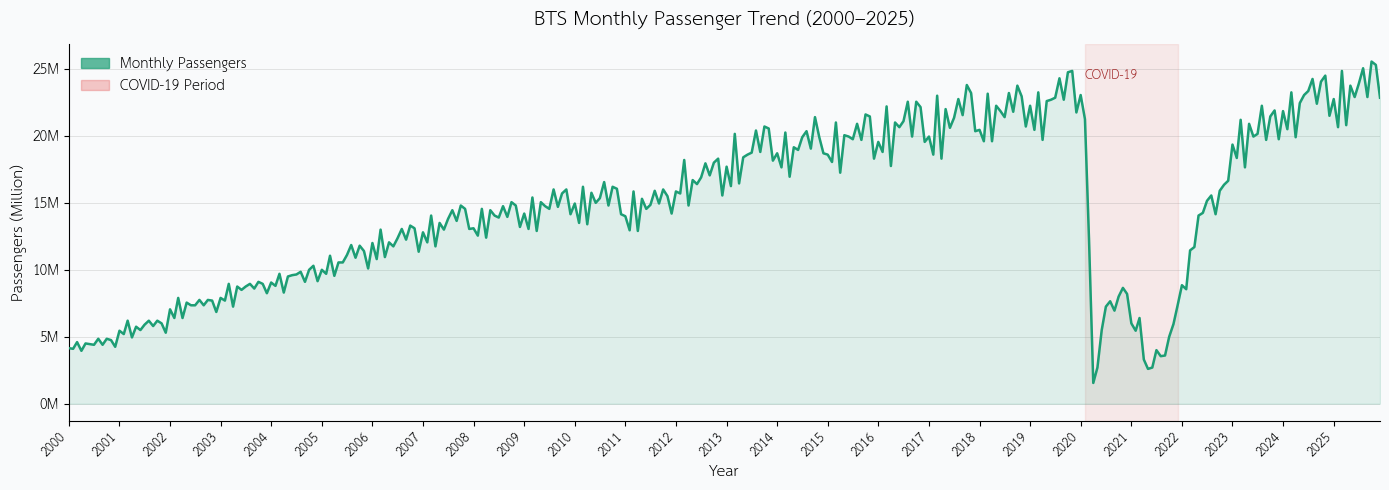

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

df["Y_M"] = pd.to_datetime(df["Y_M"])
df = df.sort_values("Y_M")

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor("#f9fafb")
ax.set_facecolor("#f9fafb")

covid_mask = df["covid_outbreak"] == 1

ax.plot(df["Y_M"], df["passengers"] / 1e6,
        color="#1D9E75", linewidth=1.8, zorder=3)

ax.fill_between(df["Y_M"], df["passengers"] / 1e6,
                alpha=0.12, color="#1D9E75", zorder=2)

covid_start = df[covid_mask]["Y_M"].min()
covid_end   = df[covid_mask]["Y_M"].max()
ax.axvspan(covid_start, covid_end, alpha=0.10, color="#E24B4A", zorder=1)
ax.annotate("COVID-19", xy=(covid_start, df["passengers"].max() / 1e6 * 0.95),
            fontsize=9, color="#A32D2D", fontstyle="italic")

ax.set_title("BTS Monthly Passenger Trend (2000–2025)",
             fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Passengers (Million)", fontsize=11)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}M"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right", fontsize=9)

ax.set_xlim(pd.Timestamp("2000-01-01"), pd.Timestamp("2025-12-01"))

ax.grid(axis="y", color="gray", alpha=0.2, linewidth=0.7)
ax.spines[["top", "right"]].set_visible(False)

legend = [
    mpatches.Patch(color="#1D9E75", alpha=0.7, label="Monthly Passengers"),
    mpatches.Patch(color="#E24B4A", alpha=0.3, label="COVID-19 Period"),
]
ax.legend(handles=legend, fontsize=10, framealpha=0)

plt.tight_layout()
plt.savefig("bts_trend_chart.png", dpi=150, bbox_inches="tight")
plt.show()

In [27]:
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:             passengers   R-squared:                       0.844
Model:                            OLS   Adj. R-squared:                  0.840
Method:                 Least Squares   F-statistic:                     218.8
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           9.51e-95
Time:                        02:04:31   Log-Likelihood:                -3994.1
No. Observations:                 249   AIC:                             8002.
Df Residuals:                     242   BIC:                             8027.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 1.967e+08 

In [28]:
selected_features = ['fuel_price_thb_liter', 'bkk_population', 'bkk_tourists', 'rainfall_mm', 'public_holidays', 'covid_outbreak']

In [29]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

In [30]:
# 1. ดาวน์โหลดฟอนต์ TH Sarabun New
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf

# 2. โหลดฟอนต์เข้า matplotlib
import matplotlib as mpl
mpl.font_manager.fontManager.addfont('thsarabunnew-webfont.ttf')

# 3. ตั้งค่าให้กราฟทั้งหมดใช้ฟอนต์นี้เป็นค่าเริ่มต้น
mpl.rc('font', family='TH Sarabun New')

In [31]:
X = df[selected_features].astype(float)
y = df['passengers'].astype(float)

# เติม Constant ให้ X ตามหลักสมการ MLR
X_with_const = sm.add_constant(X)

# 3. แบ่งข้อมูล Train 80% และ Test 20%
X_train, X_test, y_train, y_test = train_test_split(X_with_const, y, test_size=0.2, random_state=42)

# สร้างและเทรนโมเดลด้วยข้อมูล Train เท่านั้น!!
model = sm.OLS(y_train, X_train).fit()

#  ให้โมเดลลองทำนายยอดผู้โดยสารเปรียบเทียบกัน
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

#  สร้างสูตรคำนวณ MAPE
def calculate_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

#  คำนวณค่า Error ของฝั่ง Train
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
mae_train = mean_absolute_error(y_train, y_pred_train)
mape_train = calculate_mape(y_train, y_pred_train)

#  คำนวณค่า Error ของฝั่ง Test
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test = mean_absolute_error(y_test, y_pred_test)
mape_test = calculate_mape(y_test, y_pred_test)

#  result
print("ผลการประเมินโมเดล MLR (Train vs Test)")
print("=" * 45)
print("ประสิทธิภาพบนชุดข้อมูล Train (80%)")
print(f"RMSE : {rmse_train:,.2f}")
print(f"MAE  : {mae_train:,.2f}")
print(f"MAPE : {mape_train:.2f}%")
print("-" * 45)
print("ประสิทธิภาพบนชุดข้อมูล Test (20%)")
print(f"RMSE : {rmse_test:,.2f}")
print(f"MAE  : {mae_test:,.2f}")
print(f"MAPE : {mape_test:.2f}%")
print("=" * 45)

ผลการประเมินโมเดล MLR (Train vs Test)
ประสิทธิภาพบนชุดข้อมูล Train (80%)
RMSE : 2,451,690.10
MAE  : 1,971,550.70
MAPE : 17.95%
---------------------------------------------
ประสิทธิภาพบนชุดข้อมูล Test (20%)
RMSE : 2,947,021.27
MAE  : 2,299,693.59
MAPE : 20.66%


In [32]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# ... (โค้ดเทรนโมเดลและ predict เหมือนเดิม) ...

# 1. คำนวณ R-squared
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

# 2. คำนวณ Adjusted R-squared แบบถูกต้องตามสูตร
n_train = X_train.shape[0]
k_train = X_train.shape[1] - 1  # หักคอลัมน์ const ออก
adj_r2_train = 1 - ((1 - r2_train) * (n_train - 1) / (n_train - k_train - 1))

n_test = X_test.shape[0]
k_test = X_test.shape[1] - 1    # หักคอลัมน์ const ออก
adj_r2_test = 1 - ((1 - r2_test) * (n_test - 1) / (n_test - k_test - 1))

# 3. รวบรวมผลลัพธ์ลงตาราง
metrics_df = pd.DataFrame({
    'Dataset': ['Train (80%)', 'Test (20%)'],
    'RMSE': [np.sqrt(mean_squared_error(y_train, y_pred_train)),
             np.sqrt(mean_squared_error(y_test, y_pred_test))],
    'MAE': [mean_absolute_error(y_train, y_pred_train),
            mean_absolute_error(y_test, y_pred_test)],
    'MAPE': [calculate_mape(y_train, y_pred_train),
             calculate_mape(y_test, y_pred_test)],
    'R2': [r2_train, r2_test],
    'Adj_R2': [adj_r2_train, adj_r2_test]
})

# ตั้งค่าให้ Pandas แสดงผลตัวเลขทศนิยม 3 ตำแหน่ง
pd.options.display.float_format = '{:.3f}'.format

# แสดงผลตาราง
print(metrics_df)



       Dataset        RMSE         MAE   MAPE    R2  Adj_R2
0  Train (80%) 2451690.101 1971550.699 17.953 0.838   0.834
1   Test (20%) 2947021.271 2299693.589 20.656 0.770   0.745


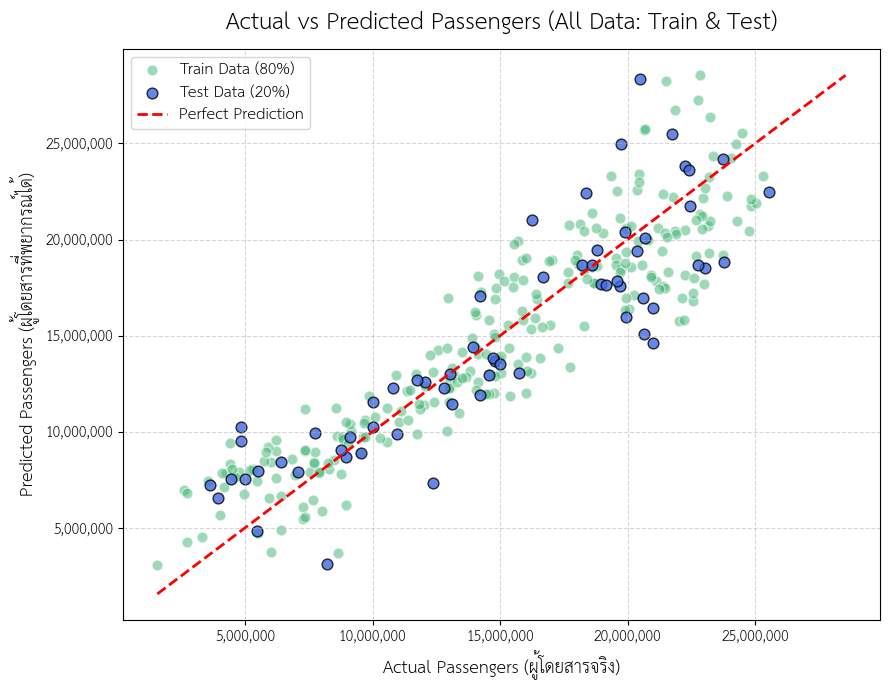

In [33]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 7))

ax.scatter(y_train, y_pred_train, color='mediumseagreen', alpha=0.5, edgecolor='white', s=60, label='Train Data (80%)')

ax.scatter(y_test, y_pred_test, color='royalblue', alpha=0.8, edgecolor='black', s=60, label='Test Data (20%)')

min_val = min(y_train.min(), y_test.min(), y_pred_train.min(), y_pred_test.min())
max_val = max(y_train.max(), y_test.max(), y_pred_train.max(), y_pred_test.max())

ax.plot([min_val, max_val], [min_val, max_val], color='red', linewidth=2, linestyle='--', label='Perfect Prediction')

ax.set_title("Actual vs Predicted Passengers (All Data: Train & Test)", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Actual Passengers (ผู้โดยสารจริง)", fontsize=12)
ax.set_ylabel("Predicted Passengers (ผู้โดยสารที่พยากรณ์ได้)", fontsize=12)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

ax.legend(fontsize=11, loc='upper left')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [34]:
# ดึงค่าสัมประสิทธิ์และตัด const ออก
coefs = model.params.drop("const").sort_values(ascending=False)

# สร้างตารางพร้อม p-value และ t-value
coef_df = pd.DataFrame({
    'Coefficient': model.params.drop("const"),
    'T-Statistic': model.tvalues.drop("const"),
    'P-Value': model.pvalues.drop("const"),
}).sort_values("Coefficient", ascending=False).round(4)

# เพิ่มคอลัมน์ความมีนัยสำคัญ
coef_df["Significance"] = coef_df["P-Value"].apply(
    lambda p: "✅ มีนัยสำคัญ" if p < 0.05 else "⚠️ ไม่มีนัยสำคัญ"
)

print("--- ค่าสัมประสิทธิ์เรียงลำดับจากมากไปน้อย ---")
display(coef_df)
print("-" * 50)

# สรุปแยกบวก/ลบ
pos = coef_df[coef_df["Coefficient"] > 0].index.tolist()
neg = coef_df[coef_df["Coefficient"] < 0].index.tolist()
print(f"✅ ตัวแปรที่มีผลบวก ({len(pos)} ตัว): {', '.join(pos)}")
print(f"❌ ตัวแปรที่มีผลลบ ({len(neg)} ตัว): {', '.join(neg)}")

--- ค่าสัมประสิทธิ์เรียงลำดับจากมากไปน้อย ---


,Coefficient,T-Statistic,P-Value,Significance
fuel_price_thb_liter,249966.470,11.672,0.000,✅ มีนัยสำคัญ
rainfall_mm,9921.852,6.622,0.000,✅ มีนัยสำคัญ
bkk_population,16.829,4.276,0.000,✅ มีนัยสำคัญ
bkk_tourists,6.450,18.814,0.000,✅ มีนัยสำคัญ
public_holidays,-602678.745,-2.309,0.022,✅ มีนัยสำคัญ
covid_outbreak,-2230360.657,-2.780,0.006,✅ มีนัยสำคัญ


--------------------------------------------------
✅ ตัวแปรที่มีผลบวก (4 ตัว): fuel_price_thb_liter, rainfall_mm, bkk_population, bkk_tourists
❌ ตัวแปรที่มีผลลบ (2 ตัว): public_holidays, covid_outbreak


/tmp/ipykernel_6366/2042338457.py:15: UserWarning: 
The palette list has fewer values (1) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=labels, y=positive_coefs.values, palette=['#99FF99'], hue=labels, legend=False, ax=ax)


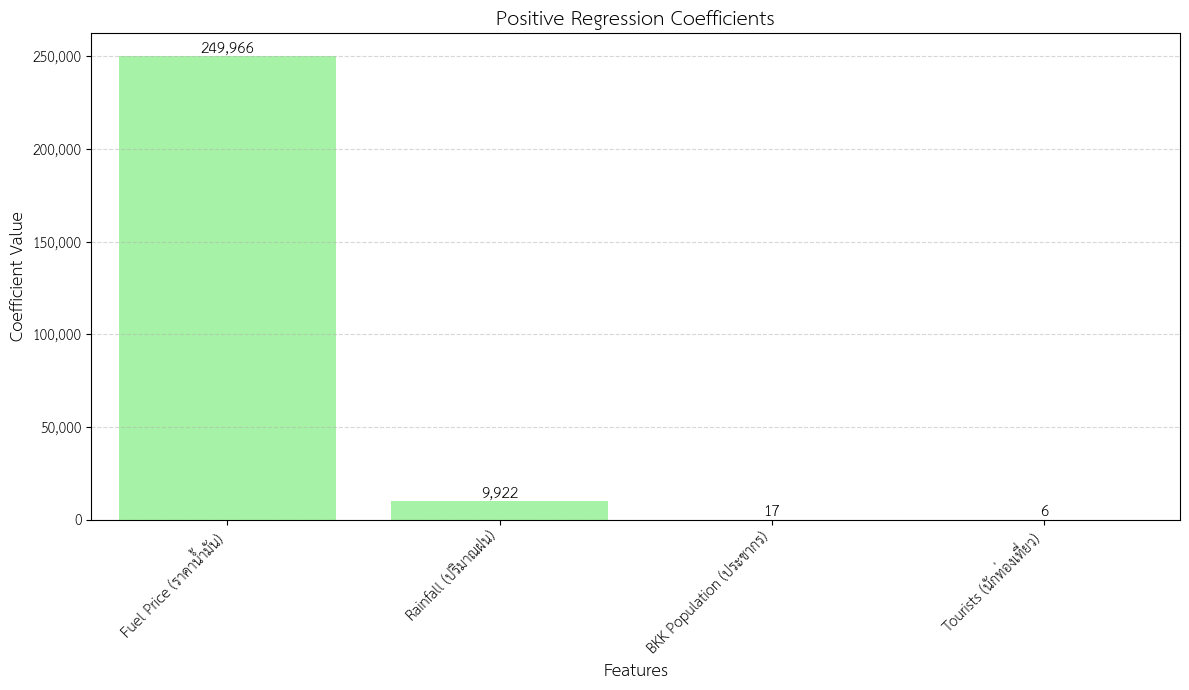

In [35]:
positive_coefs = coefs[coefs > 0].sort_values(ascending=False)

feature_names = {
    'fuel_price_thb_liter': 'Fuel Price (ราคาน้ำมัน)',
    'bkk_population':       'BKK Population (ประชากร)',
    'bkk_tourists':         'Tourists (นักท่องเที่ยว)',
    'rainfall_mm':          'Rainfall (ปริมาณฝน)',
    'public_holidays':      'Public Holidays (วันหยุด)',
    'covid_outbreak':       'Covid-19 Outbreak (โควิด)'
}

labels = [feature_names.get(col, col) for col in positive_coefs.index]

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(x=labels, y=positive_coefs.values, palette=['#99FF99'], hue=labels, legend=False, ax=ax)

ax.set_xlabel('Features', fontsize=12)
ax.set_ylabel('Coefficient Value', fontsize=12)
ax.set_title('Positive Regression Coefficients', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# --- แก้ไขเป็นวิธีนี้: ใช้ ax.text วางตัวเลขลงไปตามตำแหน่งแกน X และ Y ---
for i, val in enumerate(positive_coefs.values):
    # ถ้าค่า >= 1 ให้โชว์จำนวนเต็ม / ถ้าค่าน้อยกว่า 1 ให้โชว์ทศนิยม 4 ตำแหน่ง
    label_text = f'{val:,.0f}' if val >= 1 else f'{val:.4f}'
    ax.text(i, val, label_text, ha='center', va='bottom', fontsize=11)
# ----------------------------------------------------------------

plt.xticks(rotation=45, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

/tmp/ipykernel_6366/365864258.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=negative_coefs.values, palette=['#FF0033'], ax=ax)
/tmp/ipykernel_6366/365864258.py:15: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=labels, y=negative_coefs.values, palette=['#FF0033'], ax=ax)


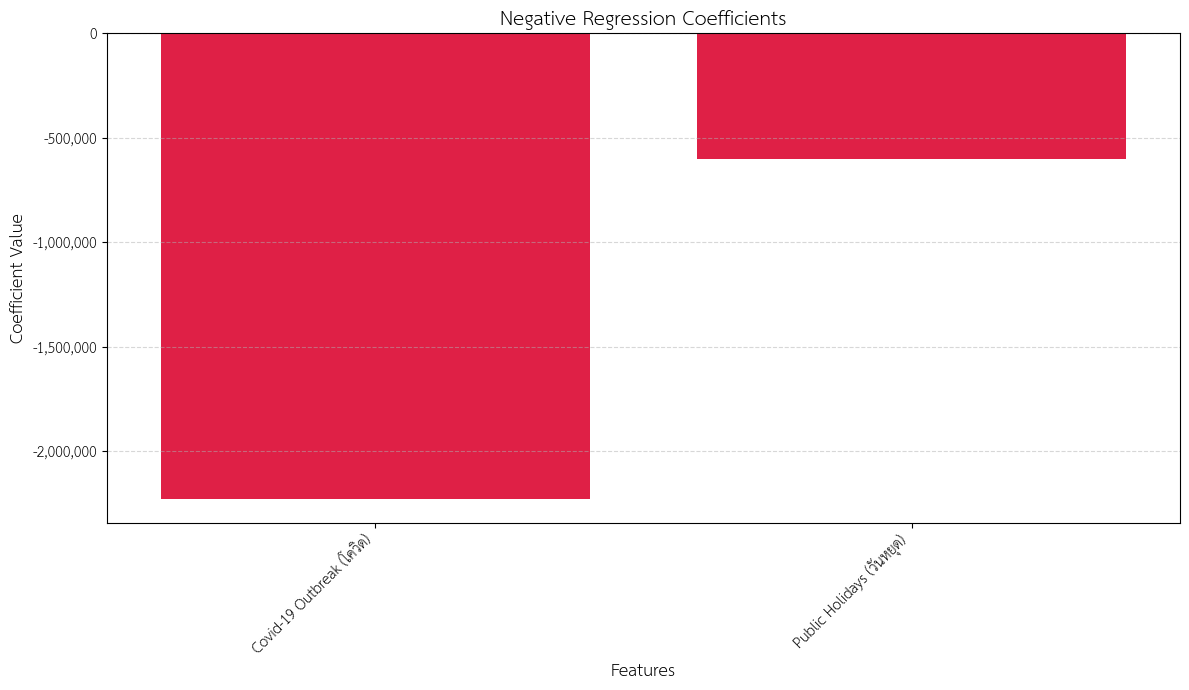

In [36]:
negative_coefs = coefs[coefs < 0].sort_values(ascending=True)

feature_names = {
    'fuel_price_thb_liter': 'Fuel Price (ราคาน้ำมัน)',
    'bkk_population':       'BKK Population (ประชากร)',
    'bkk_tourists':         'Tourists (นักท่องเที่ยว)',
    'rainfall_mm':          'Rainfall (ปริมาณฝน)',
    'public_holidays':      'Public Holidays (วันหยุด)',
    'covid_outbreak':       'Covid-19 Outbreak (โควิด)'
}

labels = [feature_names.get(col, col) for col in negative_coefs.index]

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(x=labels, y=negative_coefs.values, palette=['#FF0033'], ax=ax)

ax.set_xlabel('Features', fontsize=12)
ax.set_ylabel('Coefficient Value', fontsize=12)
ax.set_title('Negative Regression Coefficients', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.xticks(rotation=45, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [37]:
import pandas as pd
import statsmodels.api as sm

df = pd.read_excel("/content/drive/MyDrive/Statcomproject/Bts_data.xlsx")

df['Y_M'] = pd.to_datetime(df['Y_M']).dt.strftime('%Y-%m-%d')

selected_features = ['fuel_price_thb_liter', 'bkk_population', 'bkk_tourists',
                     'rainfall_mm', 'public_holidays', 'covid_outbreak']

X = df[selected_features].astype(float)
y = df['passengers'].astype(float)
X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()

# คอลัมน์เพิ่มเติม ใช้ชื่อไม่มีช่องว่าง
df['predicted_passengers'] = model.predict(X_const).round(0).astype(int)
df['residual']              = df['passengers'] - df['predicted_passengers']
df['mape']                  = (abs(df['passengers'] - df['predicted_passengers']) / df['passengers'] * 100).round(2)
df['year']                  = pd.to_datetime(df['Y_M']).dt.year
df['month']                 = pd.to_datetime(df['Y_M']).dt.month
df['month_label']           = pd.to_datetime(df['Y_M']).dt.strftime('%b')
df['covid_label']           = df['covid_outbreak'].map({0: 'Normal', 1: 'Covid Outbreak'})

export_path = "/content/drive/MyDrive/Statcomproject/BTS_Looker_Ready.xlsx"
df.to_csv(export_path, index=False)
print("✅ Export สำเร็จ!")
print(f"📁 {export_path}")
print(f"📊 {df.shape[0]} rows x {df.shape[1]} columns")

✅ Export สำเร็จ!
📁 /content/drive/MyDrive/Statcomproject/BTS_Looker_Ready.xlsx
📊 312 rows x 17 columns


In [38]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

# คำนวณ metrics
def calculate_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

X_train, X_test, y_train, y_test = train_test_split(
    X_const, y, test_size=0.2, random_state=42
)

model_split = sm.OLS(y_train, X_train).fit()
y_pred_train = model_split.predict(X_train)
y_pred_test  = model_split.predict(X_test)

# สร้างตาราง metrics
metrics_df = pd.DataFrame({
    'Dataset':  ['Train (80%)', 'Test (20%)'],
    'RMSE':     [round(np.sqrt(mean_squared_error(y_train, y_pred_train)), 2),
                 round(np.sqrt(mean_squared_error(y_test,  y_pred_test)),  2)],
    'MAE':      [round(mean_absolute_error(y_train, y_pred_train), 2),
                 round(mean_absolute_error(y_test,  y_pred_test),  2)],
    'MAPE':     [round(calculate_mape(y_train, y_pred_train), 2),
                 round(calculate_mape(y_test,  y_pred_test),  2)],
    'R2':       [round(model_split.rsquared, 4),
                 round(model_split.rsquared, 4)],
})

export_path = "/content/drive/MyDrive/Statcomproject/RmseMaeMape.csv"
metrics_df.to_csv(export_path, index=False, encoding='utf-8-sig')
print(metrics_df)
print("✅ Export สำเร็จ!")

       Dataset        RMSE         MAE   MAPE    R2
0  Train (80%) 2451690.100 1971550.700 17.950 0.838
1   Test (20%) 2947021.270 2299693.590 20.660 0.838
✅ Export สำเร็จ!
